##Nama : Sella Dianka Fitri
##Nim : 121450043
##Kelas : RB

a) Dengan menggunakan dataset Social_Network_Ads.csv selesaikan semua langkah-langkah yang ada pada modul ini, kemudain lakukan analisis perbandingan hasil evaluasi performa penggunaan model Naïve Bayes dan Support Vector Machine (SVM)!

1. Import libraries


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score


2. Import data


In [2]:
df = pd.read_csv('/content/Social_Network_Ads (1).csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


3. Data Analysis / Preprocessing

a) Drop data (menghapus kolom/atribut yang tidak dibutuhkan)

In [3]:
df = df.drop('User ID', axis=1)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


b) Deskripsi data

In [4]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


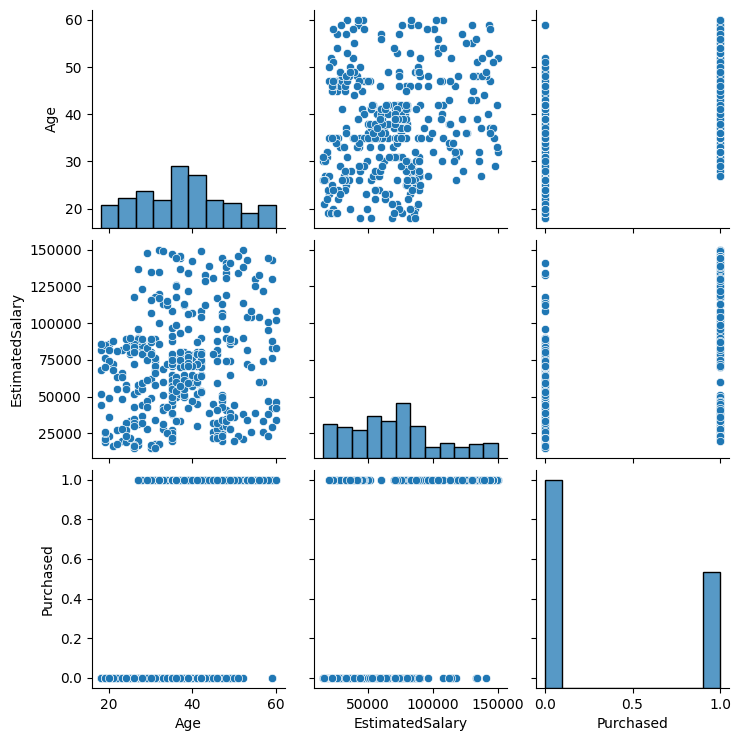

In [5]:
sns.pairplot(df)

In [6]:
df.isna().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [7]:
df = df.drop_duplicates()

In [8]:
df['Gender'] = df['Gender'].astype('category')

<ipython-input-8-a6a5791fbe1e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].astype('category')


In [9]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


c) Distribusi data

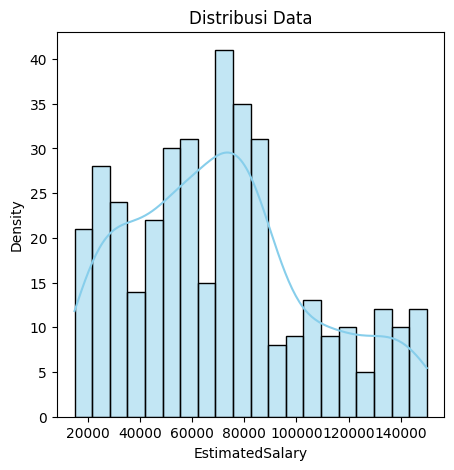

In [10]:
# Visualisasi distribusi menggunakan histogram
plt.figure(figsize=(5, 5))
sns.histplot(df['EstimatedSalary'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Menambahkan label dan judul
plt.xlabel('EstimatedSalary')
plt.ylabel('Density')
plt.title('Distribusi Data')

# Menampilkan plot
plt.show()

d) Label encoding

In [11]:
# Inisialisasi objek LabelEncoder
label_encoder = LabelEncoder()

# Menggunakan LabelEncoder pada kolom 'Gender'
df['Gender'] = label_encoder.fit_transform(df['Gender'])

<ipython-input-11-47fa88864e02>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = label_encoder.fit_transform(df['Gender'])


In [12]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


e) Correlation matrix

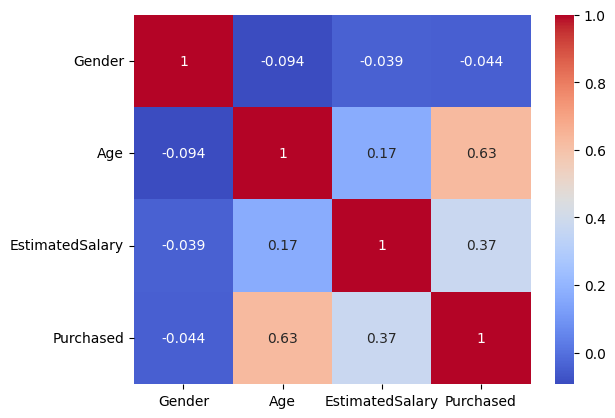

In [13]:
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [14]:
df1 = df.drop(columns = ['Gender'])

In [15]:
correlation_matrix = df1.corr()
correlation_matrix

,Age,EstimatedSalary,Purchased
Age,1.000000,0.170588,0.626505
EstimatedSalary,0.170588,1.000000,0.374928
Purchased,0.626505,0.374928,1.000000


4. Split data

a) Variabel Independen / Dependen

In [16]:
# Split data into dependent and independent variables
X = df1.iloc[:, :-1].values
y = df1.iloc[:, -1].values

b) Train / Test Split

In [17]:
#Split data into test/train net
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

5. Feature scaling

In [18]:
#Scale dataset
sc = StandardScaler()
X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

6. Train model

In [19]:
classifier = GaussianNB()

classifier.fit(X_train, y_train)

GaussianNB()

7. Predict result / Score model

In [20]:
#Make predictions on the test data
y_pred = classifier.predict(X_test)

print(np.concatenate((y_pred.reshape( len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]]


8. Evaluasi model


a) Akurasi

In [21]:
accuracy_score(y_test, y_pred)

0.9157894736842105

b) Classification report

In [22]:
print(f'Classification Report: \n{classification_report (y_test, y_pred)}')

Classification Report: 
              precision    recall  f1-score   support

           0       0.97      0.90      0.93        62
           1       0.84      0.94      0.89        33

    accuracy                           0.92        95
   macro avg       0.90      0.92      0.91        95
weighted avg       0.92      0.92      0.92        95



c) F1 score

In [23]:
print(f"F1 Score: {f1_score(y_test, y_pred)}")

F1 Score: 0.8857142857142858


d) Confusion matrix

<Axes: >

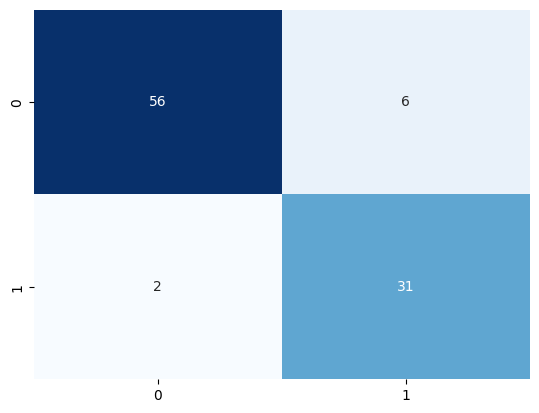

In [24]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

e) Precision-Recall curve

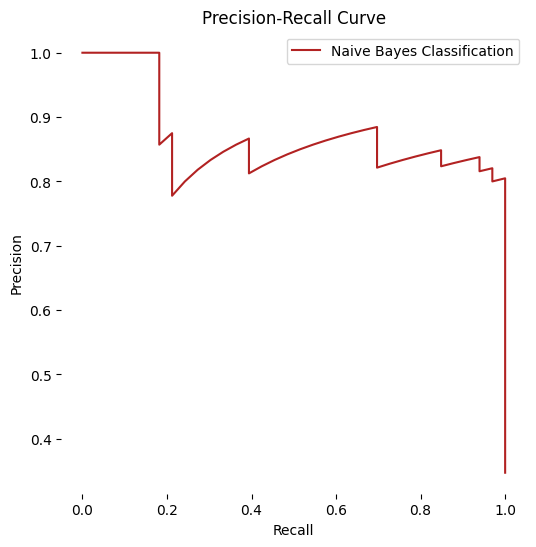

In [25]:
# Plot Precision-Recall Curve
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

# Buat plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(recall, precision, label='Naive Bayes Classification', color='firebrick')
ax.set_title('Precision-Recall Curve')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.box(False)
ax.legend()

f) AUC/ROC curve

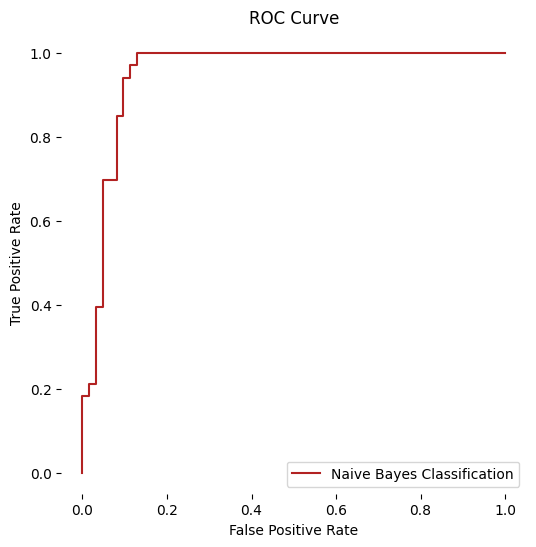

In [26]:
import matplotlib.pyplot as plt

# Plot ROC Curve
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)

# Buat plot
fig, ax = plt.subplots(figsize=(6, 6))
ax.plot(fpr, tpr, label='Naive Bayes Classification', color='firebrick')

# Set judul dan label sumbu
ax.set_title('ROC Curve')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
plt.box(False)

# Tambahkan legenda
ax.legend()


9. Visualization predictions

- Prediction results on the training set

In [27]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear',random_state=0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [28]:
y_pred = classifier.predict(X_test)

In [29]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[52, 10],
       [ 7, 26]])

<ipython-input-30-62d25c6ceaa7>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


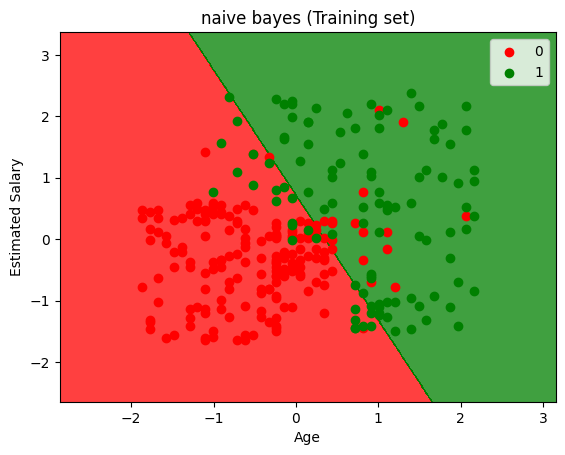

In [30]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('naive bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

- Prediction results on the test set

<ipython-input-31-89e0bbd061a3>:10: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter (X_set[y_set == j, 0], X_set[y_set == j, 1],


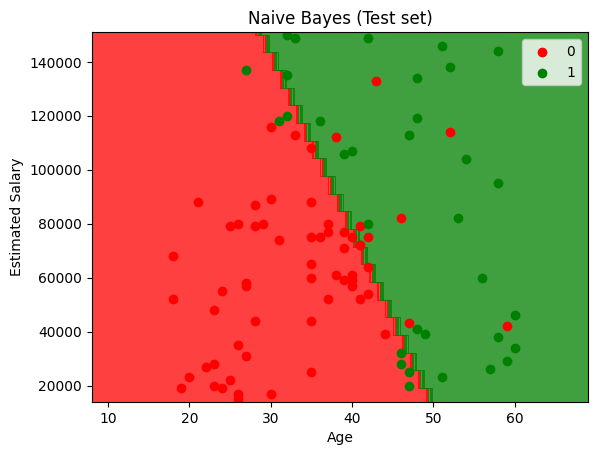

In [31]:
#Visualize prediction results on test set
X_set, y_set = sc.inverse_transform (X_test), y_test
X1, X2 = np.meshgrid (np.arange(start = X_set[:, 0].min() - 10, stop = X_set[:, 0].max() + 10, step = 1),
                      np.arange(start = X_set[:, 1].min() - 1000, stop = X_set[:, 1].max() + 1000, step = 1))
plt.contourf(X1, X2, classifier.predict(sc.transform (np.array([X1.ravel(), X2.ravel()]).T)). reshape (X1.shape),
              alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np. unique (y_set)):
    plt.scatter (X_set[y_set == j, 0], X_set[y_set == j, 1],
                 c = ListedColormap (('red', 'green')) (i), label = j)
plt.title('Naive Bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

10. Example

In [32]:
print(classifier.predict(sc.transform([[45, 97000]])))

[1]


###Praktikum 2 : Implementasi Klasifikasi Support Vector Machine(SVM)

1. Import libraries

In [33]:
from sklearn.svm import SVC

2. Import data

In [34]:
df = pd.read_csv('/content/Social_Network_Ads (1).csv')
df.head()

,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0


3. Data Analysis / Preprocessing

a) Drop data (menghapus kolom/atribut yang tidak dibutuhkan)

In [35]:
df = df.drop('User ID', axis=1)
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


b) Deskripsi data

In [36]:
df.describe()

,Age,EstimatedSalary,Purchased
count,400.000000,400.000000,400.000000
mean,37.655000,69742.500000,0.357500
std,10.482877,34096.960282,0.479864
min,18.000000,15000.000000,0.000000
25%,29.750000,43000.000000,0.000000
50%,37.000000,70000.000000,0.000000
75%,46.000000,88000.000000,1.000000
max,60.000000,150000.000000,1.000000


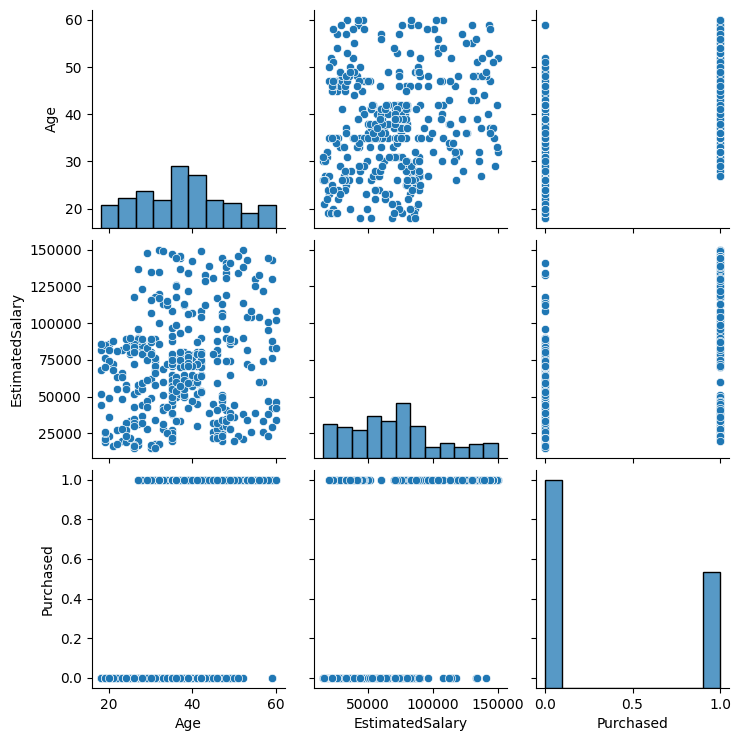

In [37]:
sns.pairplot(df)

In [38]:
df.isna().sum()

Gender             0
Age                0
EstimatedSalary    0
Purchased          0
dtype: int64

In [39]:
df = df.drop_duplicates()

In [40]:
df['Gender'] = df['Gender'].astype('category')

<ipython-input-40-a6a5791fbe1e>:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = df['Gender'].astype('category')


In [41]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,Male,19,19000,0
1,Male,35,20000,0
2,Female,26,43000,0
3,Female,27,57000,0
4,Male,19,76000,0


c) Distribusi data

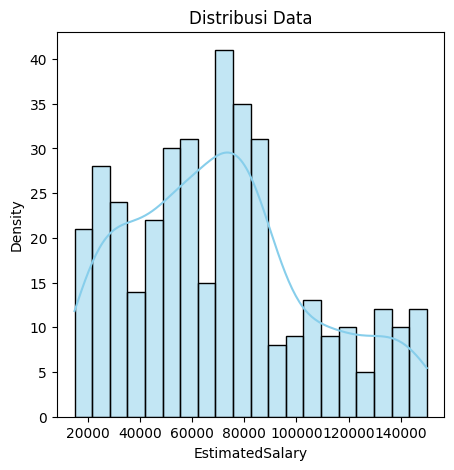

In [42]:
# Visualisasi distribusi menggunakan histogram
plt.figure(figsize=(5, 5))
sns.histplot(df['EstimatedSalary'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Menambahkan label dan judul
plt.xlabel('EstimatedSalary')
plt.ylabel('Density')
plt.title('Distribusi Data')

# Menampilkan plot
plt.show()

d) Label encoding

In [43]:
# Inisialisasi objek LabelEncoder
label_encoder = LabelEncoder()

# Menggunakan LabelEncoder pada kolom 'Gender'
df['Gender'] = label_encoder.fit_transform(df['Gender'])

<ipython-input-43-47fa88864e02>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = label_encoder.fit_transform(df['Gender'])


In [44]:
df.head()

,Gender,Age,EstimatedSalary,Purchased
0,1,19,19000,0
1,1,35,20000,0
2,0,26,43000,0
3,0,27,57000,0
4,1,19,76000,0


e) Correlation matrix

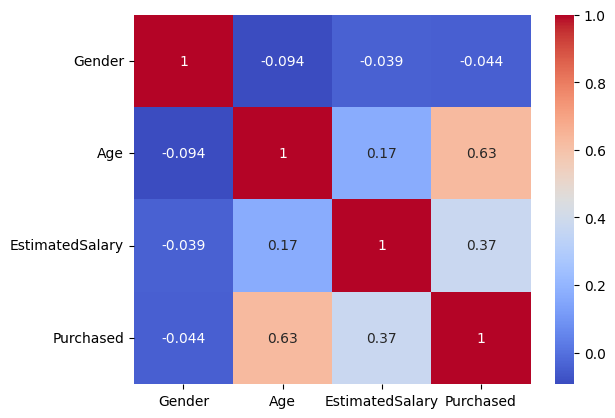

In [45]:
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [46]:
df1 = df.drop(columns = ['Gender'])

In [47]:
correlation_matrix = df1.corr()
correlation_matrix

,Age,EstimatedSalary,Purchased
Age,1.000000,0.170588,0.626505
EstimatedSalary,0.170588,1.000000,0.374928
Purchased,0.626505,0.374928,1.000000


6. Train model

In [48]:
#Classifier
classifier = SVC(kernel='linear', random_state=0, probability=True)
classifier.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=0)

7. Predict result / Score model

In [49]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [1 1]
 [1 0]
 [0 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]]


8. Evaluasi model

a) Akurasi

In [50]:
accuracy_score(y_test, y_pred)

0.8210526315789474

b) Classification report

In [51]:
print(f'classification report : \n{classification_report(y_test, y_pred)}')

classification report : 
              precision    recall  f1-score   support

           0       0.88      0.84      0.86        62
           1       0.72      0.79      0.75        33

    accuracy                           0.82        95
   macro avg       0.80      0.81      0.81        95
weighted avg       0.83      0.82      0.82        95



c) F1 score

In [52]:
print(f'F1 score : {f1_score(y_test, y_pred)}')

F1 score : 0.7536231884057971


d) Confusion matrix

<Axes: >

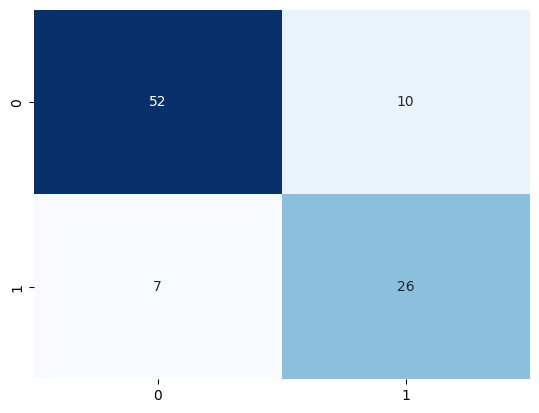

In [53]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

e) Precision-Recall curve

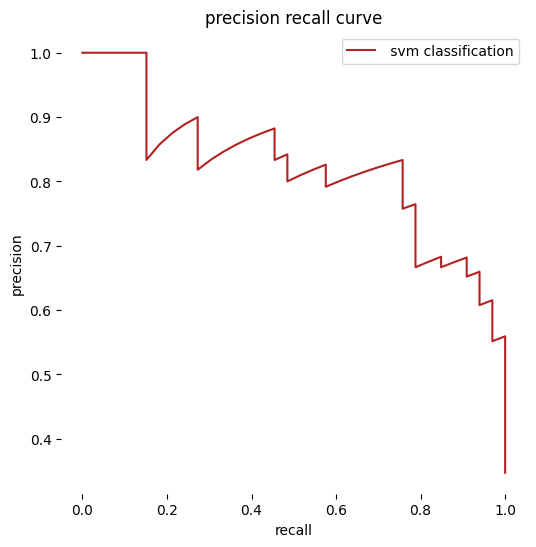

In [54]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(recall, precision, label = ' svm classification', color = 'firebrick')
ax.set_title('precision recall curve')
ax.set_xlabel('recall')
ax.set_ylabel('precision')
plt.box(False)
ax.legend();

f) AUC/ROC curve

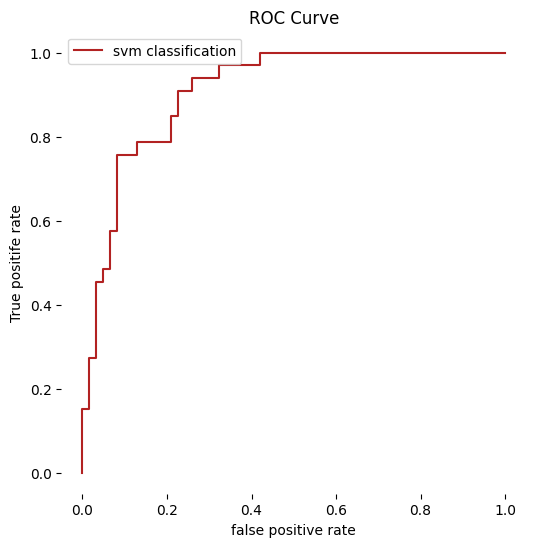

In [55]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr, tpr, label='svm classification', color ='firebrick')
ax.set_title('ROC Curve')
ax.set_xlabel('false positive rate')
ax.set_ylabel('True positife rate')
plt.box(False)
ax.legend();

9. Visualization predictions

* Prediction results on the training set

<ipython-input-56-d7201d080003>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


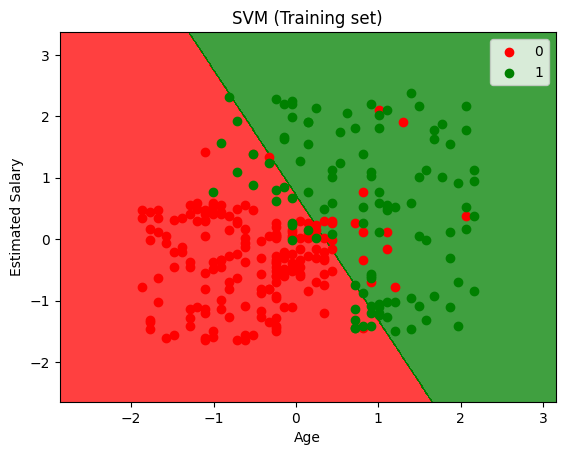

In [56]:
# Visualising the Training set results for 'rbf' kernel
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

* Prediction results on the test set

<ipython-input-57-13f06b9dc916>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


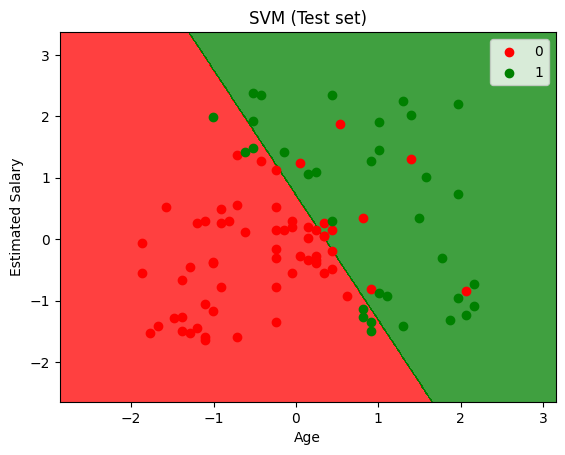

In [57]:
# Visualising the Test set results for 'rbf' Kernel
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

10. Example

In [58]:
print(classifier.predict(sc.transform([[30, 87000]])))

[0]


## b) Pilih minimal 3 dataset yang ada pada http://bit.ly/45VVB6X . Kemudian lakukan klasifikasi dengan model Naïve Bayes dan Support Vector Machine (SVM)!. Analisis data dengan hasil yang anda dapatkan !. Buat laporan dalam file PDF yang berisi:
## i) Deskripsikan dan eksplor data yang anda pilih,
## ii) flowchart praktikum,
## iii) hasil (berupa tabel) dan analisis hasil (deadline 2 hari)

## 1. Penguin Dataset

### Naive Bayes

1. Import libraries


In [59]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

2. Import data


In [60]:
df = pd.read_csv("/content/penguins (1).csv")
df.head()

,Unnamed: 0,bill_length,bill_depth,flipper_length,body_mass,species
0,0,39.1,18.7,181.0,3750.0,Adelie
1,1,39.5,17.4,186.0,3800.0,Adelie
2,2,40.3,18.0,195.0,3250.0,Adelie
3,3,36.7,19.3,193.0,3450.0,Adelie
4,4,39.3,20.6,190.0,3650.0,Adelie


3. Data Analysis / Preprocessing

a) Drop data (menghapus kolom/atribut yang tidak dibutuhkan)

In [61]:
df = df.drop('Unnamed: 0', axis=1)
df.head()

,bill_length,bill_depth,flipper_length,body_mass,species
0,39.1,18.7,181.0,3750.0,Adelie
1,39.5,17.4,186.0,3800.0,Adelie
2,40.3,18.0,195.0,3250.0,Adelie
3,36.7,19.3,193.0,3450.0,Adelie
4,39.3,20.6,190.0,3650.0,Adelie


b) Deskripsi data

In [62]:
df.describe()

,bill_length,bill_depth,flipper_length,body_mass
count,333.000000,333.000000,333.000000,333.000000
mean,43.992793,17.164865,200.966967,4207.057057
std,5.468668,1.969235,14.015765,805.215802
min,32.100000,13.100000,172.000000,2700.000000
25%,39.500000,15.600000,190.000000,3550.000000
50%,44.500000,17.300000,197.000000,4050.000000
75%,48.600000,18.700000,213.000000,4775.000000
max,59.600000,21.500000,231.000000,6300.000000


c) Distribusi data

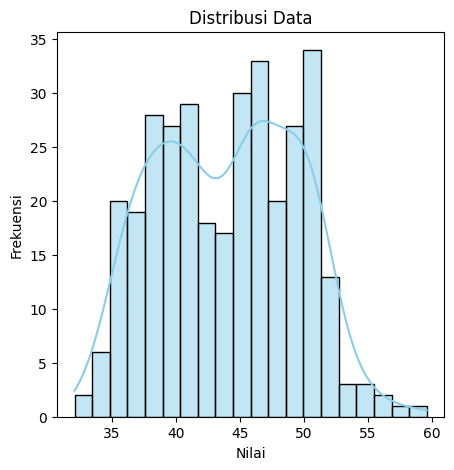

In [63]:
# Visualisasi distribusi menggunakan histogram
plt.figure(figsize=(5, 5))
sns.histplot(df['bill_length'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Menambahkan label dan judul
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')
plt.title('Distribusi Data')

# Menampilkan plot
plt.show()

d) Label encoding

In [64]:
# Inisialisasi objek LabelEncoder
label_encoder = LabelEncoder()

# Menggunakan LabelEncoder pada kolom 'Gender'
df['species'] = label_encoder.fit_transform(df['species'])

In [65]:
df.head()

,bill_length,bill_depth,flipper_length,body_mass,species
0,39.1,18.7,181.0,3750.0,0
1,39.5,17.4,186.0,3800.0,0
2,40.3,18.0,195.0,3250.0,0
3,36.7,19.3,193.0,3450.0,0
4,39.3,20.6,190.0,3650.0,0


e) Correlation matrix

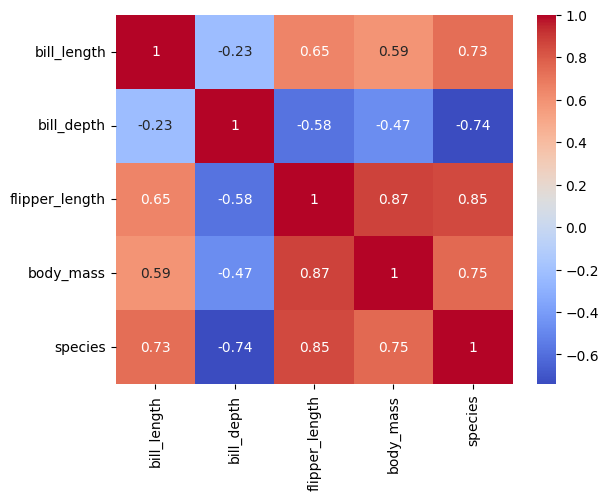

In [66]:
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [67]:
correlation_matrix

,bill_length,bill_depth,flipper_length,body_mass,species
bill_length,1.000000,-0.228626,0.653096,0.589451,0.730548
bill_depth,-0.228626,1.000000,-0.577792,-0.472016,-0.740346
flipper_length,0.653096,-0.577792,1.000000,0.872979,0.850737
body_mass,0.589451,-0.472016,0.872979,1.000000,0.750434
species,0.730548,-0.740346,0.850737,0.750434,1.000000


In [68]:
df1 = df.drop(columns = ['flipper_length', 'body_mass'])

4. Split data

a) Variabel Independen / Dependen

In [69]:
X = df1.iloc[:, :-1].values
y = df1.iloc[:, -1].values

b) Train / Test Split

In [70]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

5. Feature scaling

In [71]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

6. Train model

In [72]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

7. Predict result

In [73]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape( len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [2 2]
 [1 1]
 [2 2]
 [2 2]
 [1 1]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [2 2]
 [1 1]
 [2 2]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [1 2]
 [0 0]
 [1 1]
 [2 2]
 [0 0]
 [2 2]
 [0 0]
 [2 1]
 [2 2]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [2 2]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 2]
 [2 2]
 [2 2]
 [1 1]
 [2 2]
 [2 2]
 [1 1]
 [2 2]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [1 1]]


8. Evaluasi model

a) Akurasi

In [74]:
accuracy_score(y_test, y_pred)

0.9523809523809523

b) Classification report

In [75]:
print(f'classification report : \n{classification_report(y_test, y_pred)}')

classification report : 
              precision    recall  f1-score   support

           0       0.98      1.00      0.99        42
           1       0.87      0.87      0.87        15
           2       0.96      0.93      0.94        27

    accuracy                           0.95        84
   macro avg       0.93      0.93      0.93        84
weighted avg       0.95      0.95      0.95        84



c) F1 score

In [76]:
f1_scores = f1_score(y_test, y_pred, average=None)
print(f'F1 score for each class: {f1_scores}')

F1 score for each class: [0.98823529 0.86666667 0.94339623]


d) Confusion matrix

<Axes: >

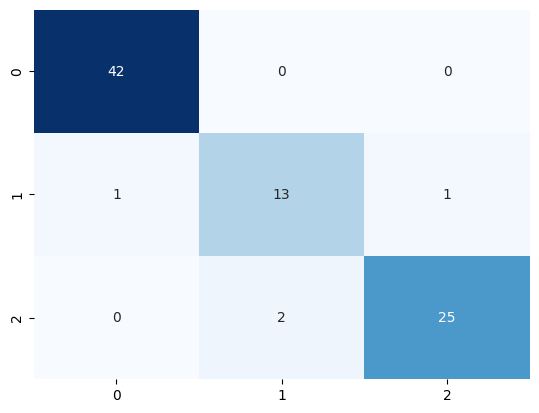

In [77]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

e) Precision-Recall curve

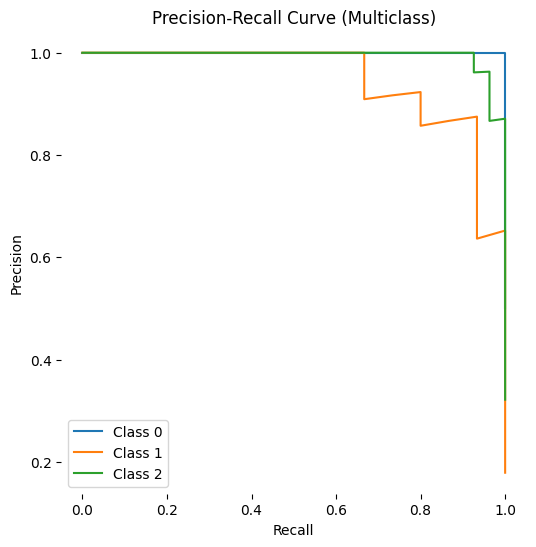

In [78]:
from sklearn.preprocessing import label_binarize

# Binarize label untuk mendukung multiclass
y_test_bin = label_binarize(y_test, classes=classifier.classes_)

# Mendapatkan nilai probabilitas untuk setiap kelas
y_pred_proba = classifier.predict_proba(X_test)

# Inisialisasi variabel untuk menyimpan precision dan recall
precision = dict()
recall = dict()
thresholds = dict()

# Menghitung precision dan recall untuk setiap kelas
for i in range(len(classifier.classes_)):
    precision[i], recall[i], thresholds[i] = precision_recall_curve(y_test_bin[:, i], y_pred_proba[:, i])

# Plotting precision-recall curve untuk setiap kelas
fig, ax = plt.subplots(figsize=(6, 6))

for i in range(len(classifier.classes_)):
    ax.plot(recall[i], precision[i], label=f'Class {classifier.classes_[i]}')

ax.set_title('Precision-Recall Curve (Multiclass)')
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.box(False)
ax.legend()
plt.show()

9. Visualization predictions

* Prediction results on the training set

In [79]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear',random_state=0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [80]:
y_pred = classifier.predict(X_test)


In [81]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[42,  0,  0],
       [ 0, 14,  1],
       [ 0,  1, 26]])

<ipython-input-82-b0e5ab3b7865>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


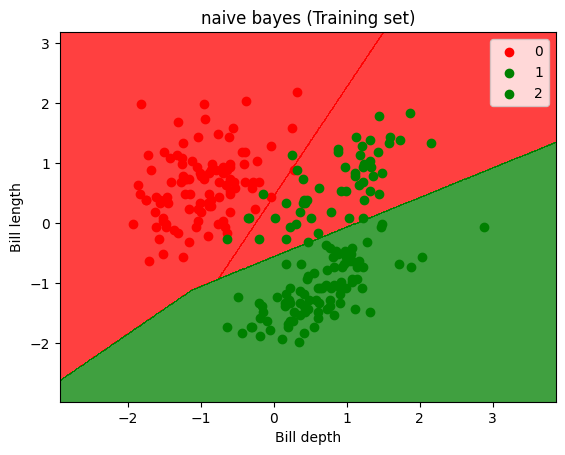

In [82]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('naive bayes (Training set)')
plt.xlabel('Bill depth')
plt.ylabel('Bill length')
plt.legend()
plt.show()

* Prediction result on the test set

<ipython-input-83-ea9c3b79831c>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


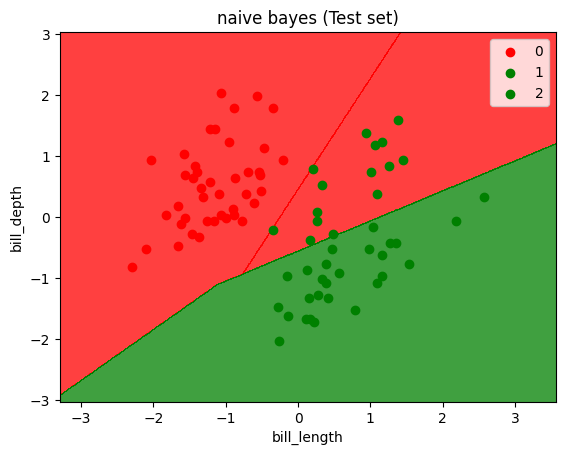

In [83]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('naive bayes (Test set)')
plt.xlabel('bill_length')
plt.ylabel('bill_depth')
plt.legend()
plt.show()

10. Example

In [84]:
print(classifier.predict(sc.transform([[40.3,  20.6]])))

[0]


### SVM

1. Import Library

In [85]:
from sklearn.svm import SVC

2. Train Model

In [86]:
classifier = SVC(kernel='linear', random_state=0, probability=True)
classifier.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=0)

3. Predict result/score model

In [87]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [2 2]
 [1 1]
 [2 2]
 [2 2]
 [1 1]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [2 2]
 [1 1]
 [2 2]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [0 0]
 [1 1]
 [2 2]
 [0 0]
 [2 2]
 [0 0]
 [1 1]
 [2 2]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [2 2]
 [0 0]
 [2 2]
 [0 0]
 [1 2]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [2 2]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [2 2]
 [2 2]
 [2 2]
 [1 1]
 [2 2]
 [2 2]
 [2 1]
 [2 2]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [2 2]
 [2 2]
 [2 2]
 [2 2]
 [1 1]]


4. Evaluasi model

a) Akurasi

In [88]:
accuracy_score(y_test, y_pred)

0.9761904761904762

b) Classification report

In [89]:
print(f'classification report : \n{classification_report(y_test, y_pred)}')

classification report : 
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        42
           1       0.93      0.93      0.93        15
           2       0.96      0.96      0.96        27

    accuracy                           0.98        84
   macro avg       0.97      0.97      0.97        84
weighted avg       0.98      0.98      0.98        84



c) F1 score

In [90]:
f1_scores = f1_score(y_test, y_pred, average=None)
print(f'F1 score for each class: {f1_scores}')

F1 score for each class: [1.         0.93333333 0.96296296]


d) Confusion matrix

<Axes: >

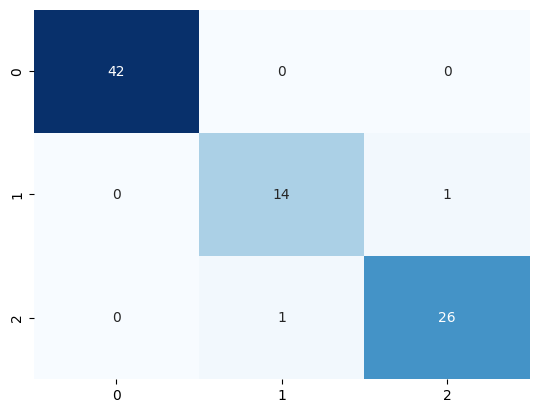

In [91]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

5. Visualization predictions

<ipython-input-92-87ea19553ead>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


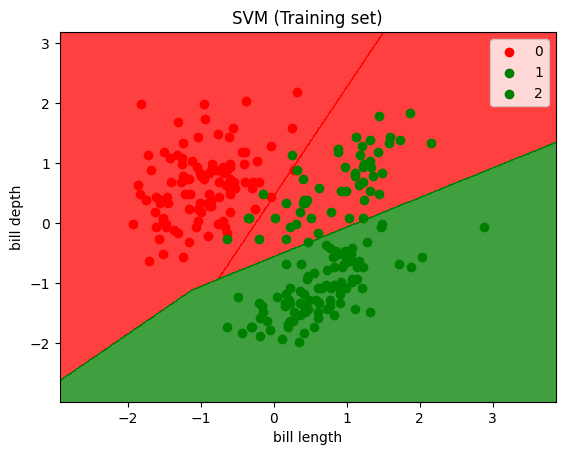

In [92]:
# Visualising the Training set results for 'rbf' kernel
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Training set)')
plt.xlabel('bill length')
plt.ylabel('bill depth')
plt.legend()
plt.show()

<ipython-input-93-ea6b4ae32d0c>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


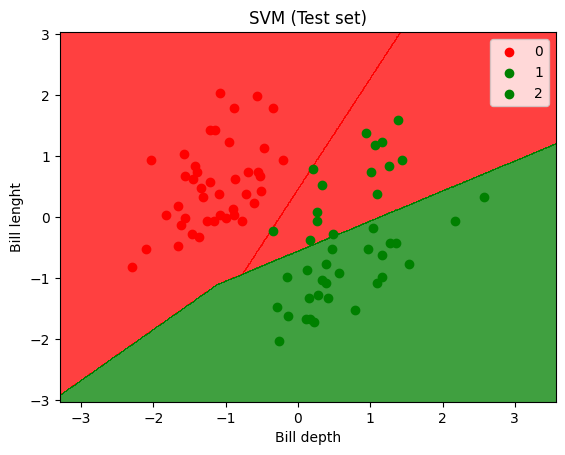

In [93]:
# Visualising the Test set results for 'rbf' Kernel
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Test set)')
plt.xlabel('Bill depth')
plt.ylabel('Bill lenght')
plt.legend()
plt.show()

6. Example

In [94]:
print(classifier.predict(sc.transform([[40.3, 20.6]])))

[0]


## 2. Student Dataset

### Naive Bayes

1. Import Library

In [95]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

2. Import Data

In [96]:
df = pd.read_csv("/content/student (2).csv")
df.head()

,Student_id,Age,Gender,Grade,Employed
0,1,19,Male,1st Class,yes
1,2,20,Female,2nd Class,no
2,3,18,Male,1st Class,no
3,4,21,Female,2nd Class,no
4,5,19,Male,1st Class,no


3. Data Analysis / Preprocessing

a) Drop data (menghapus kolom/atribut yang tidak dibutuhkan)

In [97]:
df = df.drop('Student_id', axis=1)
df.head()

,Age,Gender,Grade,Employed
0,19,Male,1st Class,yes
1,20,Female,2nd Class,no
2,18,Male,1st Class,no
3,21,Female,2nd Class,no
4,19,Male,1st Class,no


b) Deskripsi data

In [98]:
df.describe()

,Age
count,232.000000
mean,19.896552
std,1.030944
min,18.000000
25%,19.000000
50%,20.000000
75%,21.000000
max,22.000000


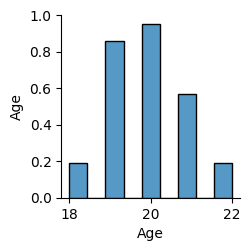

In [99]:
import seaborn as sns
sns.pairplot(df)

Data cleaning and preparation

In [100]:
df.isna().sum()

Age         0
Gender      0
Grade       0
Employed    0
dtype: int64

In [101]:
df = df.drop_duplicates()

In [102]:
df.head()

,Age,Gender,Grade,Employed
0,19,Male,1st Class,yes
1,20,Female,2nd Class,no
2,18,Male,1st Class,no
3,21,Female,2nd Class,no
4,19,Male,1st Class,no


c) Distribusi data

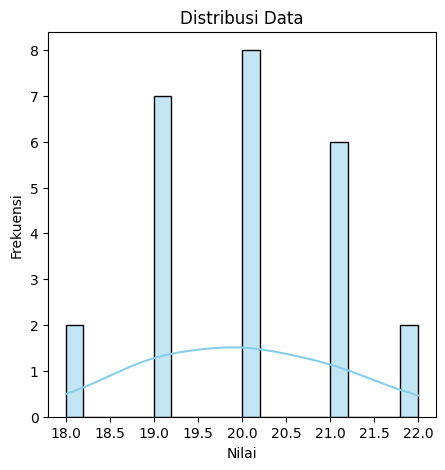

In [103]:
# Visualisasi distribusi menggunakan histogram
plt.figure(figsize=(5, 5))
sns.histplot(df['Age'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Menambahkan label dan judul
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')
plt.title('Distribusi Data')

# Menampilkan plot
plt.show()

d) Label encoding

In [104]:
# Inisialisasi objek LabelEncoder
label_encoder = LabelEncoder()

# Menggunakan LabelEncoder pada kolom 'Gender'
df['Gender'] = label_encoder.fit_transform(df['Gender'])
df['Grade'] = label_encoder.fit_transform(df['Grade'])
df['Employed'] = label_encoder.fit_transform(df['Employed'])

<ipython-input-104-a8d4eb587a23>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Gender'] = label_encoder.fit_transform(df['Gender'])
<ipython-input-104-a8d4eb587a23>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Grade'] = label_encoder.fit_transform(df['Grade'])
<ipython-input-104-a8d4eb587a23>:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://panda

In [105]:
df.head()

,Age,Gender,Grade,Employed
0,19,1,0,1
1,20,0,1,0
2,18,1,0,0
3,21,0,1,0
4,19,1,0,0


e) Correlation matrix

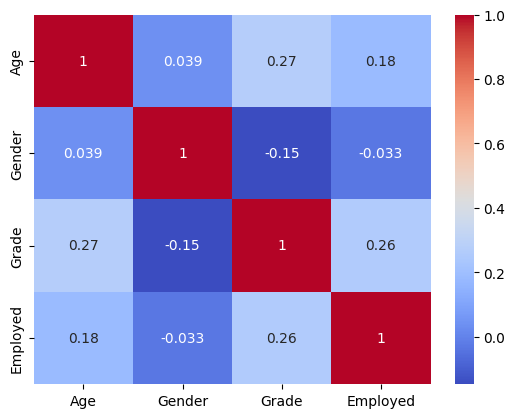

In [106]:
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [107]:
df1 = df.drop(columns=['Gender'])

In [108]:
correlation_matrix = df1.corr()
correlation_matrix

,Age,Grade,Employed
Age,1.000000,0.272537,0.182069
Grade,0.272537,1.000000,0.257742
Employed,0.182069,0.257742,1.000000


4. Split data

a) Variabel Independen / Dependen

In [109]:
X = df1.iloc[:, :-1].values
y = df1.iloc[:, -1].values

b) Train / Test Split

In [110]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

5. Feature scaling

In [111]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

6. Train model

In [112]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

7. Predict result

In [113]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape( len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]]


8. Evaluasi model

a) Akurasi

In [114]:
accuracy_score(y_test, y_pred)

0.7142857142857143

b) Classification report

In [115]:
print(f'classification report : \n{classification_report(y_test, y_pred)}')

classification report : 
              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       0.00      0.00      0.00         2

    accuracy                           0.71         7
   macro avg       0.36      0.50      0.42         7
weighted avg       0.51      0.71      0.60         7



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


c) F1 Score

In [116]:
print(f'F1 score : {f1_score(y_test, y_pred)}')

F1 score : 0.0


d) Confusion matrix

<Axes: >

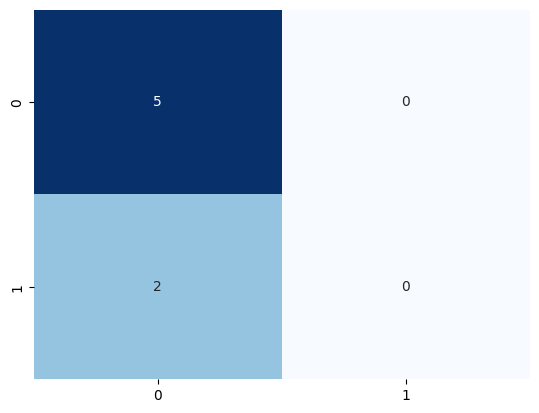

In [117]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

e) Precision-Recall curve

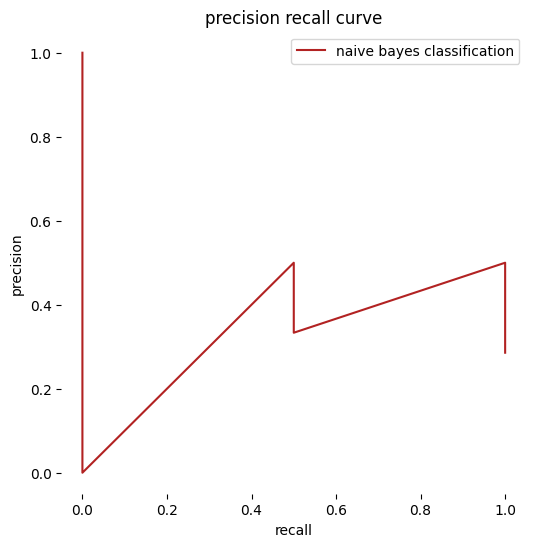

In [118]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(recall, precision, label = 'naive bayes classification', color = 'firebrick')
ax.set_title('precision recall curve')
ax.set_xlabel('recall')
ax.set_ylabel('precision')
plt.box(False)
ax.legend();

f) AUC/ROC curve

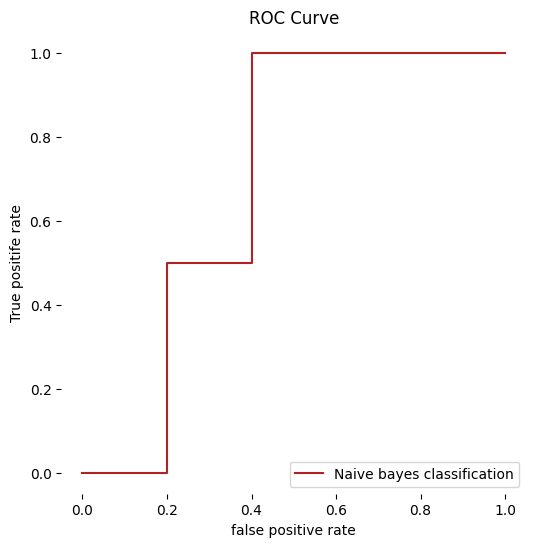

In [119]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr, tpr, label='Naive bayes classification', color ='firebrick')
ax.set_title('ROC Curve')
ax.set_xlabel('false positive rate')
ax.set_ylabel('True positife rate')
plt.box(False)
ax.legend();

9. Visualisation prediction

* Prediction result on the training set

In [120]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear',random_state=0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [121]:
y_pred = classifier.predict(X_test)

In [122]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[5, 0],
       [2, 0]])

<ipython-input-123-cba2ecbea2a5>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


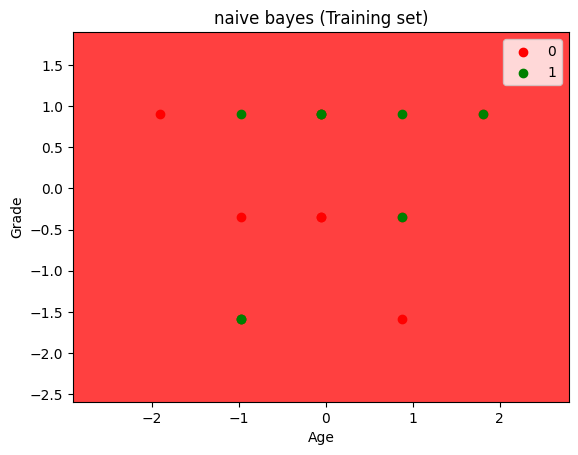

In [123]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('naive bayes (Training set)')
plt.xlabel('Age')
plt.ylabel('Grade')
plt.legend()
plt.show()

* Prediction result on the test set

<ipython-input-124-448df62e80aa>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


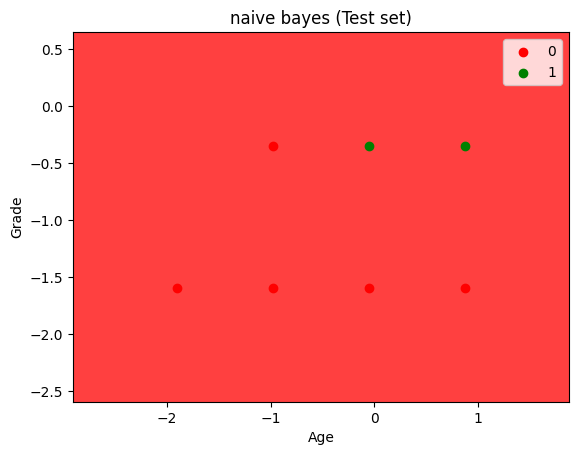

In [124]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('naive bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Grade')
plt.legend()
plt.show()

10. Example

In [125]:
print(classifier.predict(sc.transform([[20,  1]])))

[0]


### SVM

1. Import Library

In [126]:
from sklearn.svm import SVC

2. Train Model

In [127]:
classifier = SVC(kernel='linear', random_state=0, probability=True)
classifier.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=0)

3. Predict result/score model

In [128]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]]


4. Evaluasi model

a) Akurasi

In [129]:
accuracy_score(y_test, y_pred)

0.7142857142857143

b) Classification report

In [130]:
print(f'classification report : \n{classification_report(y_test, y_pred)}')

classification report : 
              precision    recall  f1-score   support

           0       0.71      1.00      0.83         5
           1       0.00      0.00      0.00         2

    accuracy                           0.71         7
   macro avg       0.36      0.50      0.42         7
weighted avg       0.51      0.71      0.60         7



/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))
/usr/local/lib/python3.10/dist-packages/sklearn/metrics/_classification.py:1344: UndefinedMetricWarning: Precision and F-score are ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, msg_start, len(result))


c) F1 score

In [131]:
print(f'F1 score : {f1_score(y_test, y_pred)}')

F1 score : 0.0


d) Confusion matrix

<Axes: >

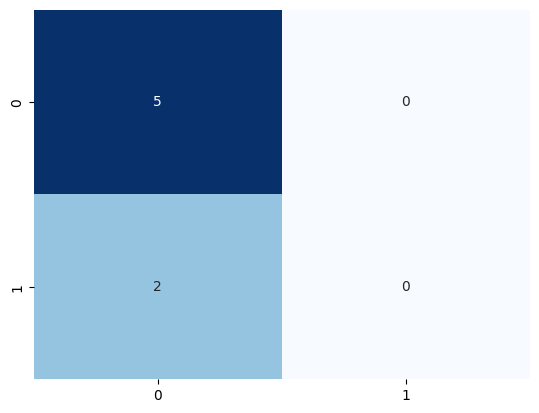

In [132]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

e) Precision recall curve

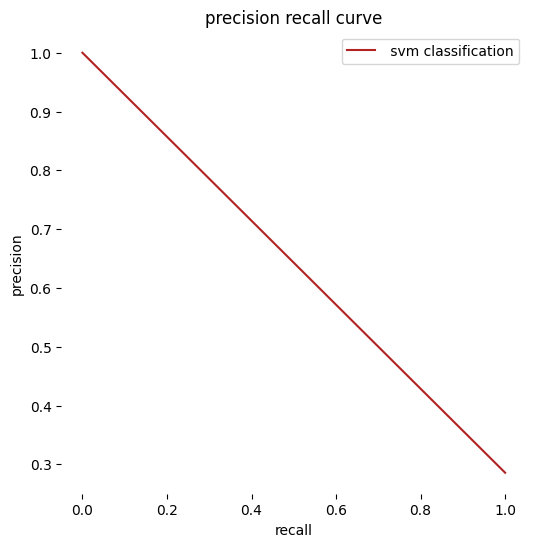

In [133]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(recall, precision, label = ' svm classification', color = 'firebrick')
ax.set_title('precision recall curve')
ax.set_xlabel('recall')
ax.set_ylabel('precision')
plt.box(False)
ax.legend();

f) AUC/ROC curve

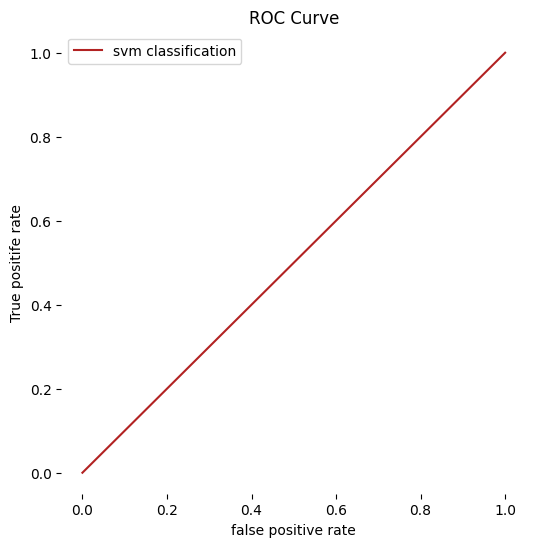

In [134]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr, tpr, label='svm classification', color ='firebrick')
ax.set_title('ROC Curve')
ax.set_xlabel('false positive rate')
ax.set_ylabel('True positife rate')
plt.box(False)
ax.legend();

5. Visualisation predictions

<ipython-input-135-d7201d080003>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


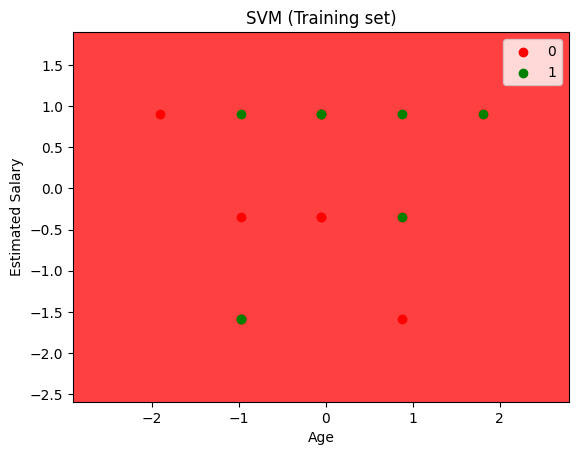

In [135]:
# Visualising the Training set results for 'rbf' kernel
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Training set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

<ipython-input-136-13f06b9dc916>:11: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],


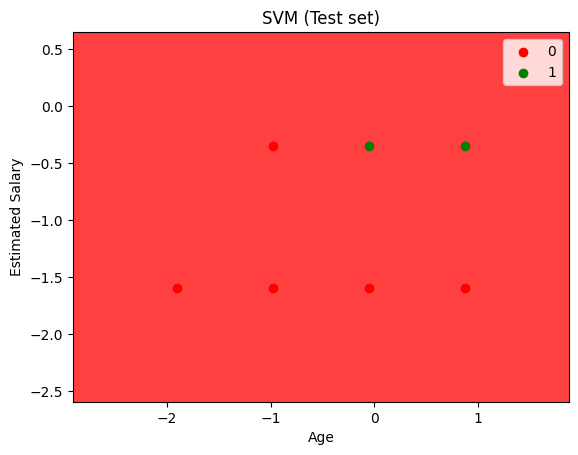

In [136]:
# Visualising the Test set results for 'rbf' Kernel
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('SVM (Test set)')
plt.xlabel('Age')
plt.ylabel('Estimated Salary')
plt.legend()
plt.show()

6. Example

In [137]:
print(classifier.predict(sc.transform([[20, 1]])))

[0]


## 3. Diabetes Dataset

### Naive Bayes

1. Import Library

In [138]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

2. Import Data

In [140]:
df = pd.read_csv('/content/diabetes_RS1 (1).csv')
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


3. Data Analysis / Preprocessing

a) Drop data (menghapus kolom/atribut yang tidak dibutuhkan)

In [141]:
df = df.drop('Pregnancies', axis=1)
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,148,72,35,0,33.6,0.627,50,1
1,85,66,29,0,26.6,0.351,31,0
2,183,64,0,0,23.3,0.672,32,1
3,89,66,23,94,28.1,0.167,21,0
4,137,40,35,168,43.1,2.288,33,1


b) Deskripsi data

In [142]:
df.describe()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


c) Distribusi data

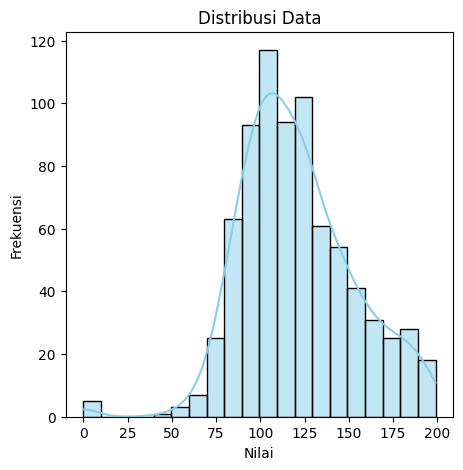

In [143]:
# Visualisasi distribusi menggunakan histogram
plt.figure(figsize=(5, 5))
sns.histplot(df['Glucose'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Menambahkan label dan judul
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')
plt.title('Distribusi Data')

# Menampilkan plot
plt.show()

d) Label encoding

In [144]:
# Inisialisasi objek LabelEncoder
label_encoder = LabelEncoder()

# Menggunakan LabelEncoder pada kolom 'Gender'
df['Glucose'] = label_encoder.fit_transform(df['Glucose'])
df['BloodPressure'] = label_encoder.fit_transform(df['BloodPressure'])
df['SkinThickness'] = label_encoder.fit_transform(df['SkinThickness'])
df['Insulin'] = label_encoder.fit_transform(df['Glucose'])

In [145]:
df.head()

,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,86,22,28,86,33.6,0.627,50,1
1,23,19,22,23,26.6,0.351,31,0
2,121,17,0,121,23.3,0.672,32,1
3,27,19,16,27,28.1,0.167,21,0
4,75,4,28,75,43.1,2.288,33,1


e) Correlation matrix

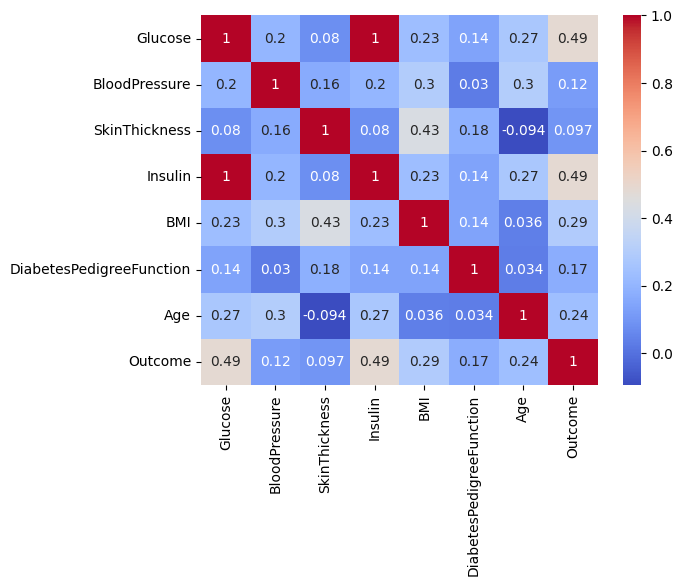

In [146]:
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [178]:
df1 = df.drop(columns = ['Glucose'])

In [179]:
correlation_matrix = df1.corr()
correlation_matrix

,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
BloodPressure,1.000000,0.164941,0.201029,0.298250,0.029518,0.301522,0.117401
SkinThickness,0.164941,1.000000,0.079944,0.434387,0.180627,-0.094057,0.097274
Insulin,0.201029,0.079944,1.000000,0.231353,0.138976,0.271192,0.486455
BMI,0.298250,0.434387,0.231353,1.000000,0.140647,0.036242,0.292695
DiabetesPedigreeFunction,0.029518,0.180627,0.138976,0.140647,1.000000,0.033561,0.173844
Age,0.301522,-0.094057,0.271192,0.036242,0.033561,1.000000,0.238356
Outcome,0.117401,0.097274,0.486455,0.292695,0.173844,0.238356,1.000000


4. Split data

a) Variabel Independen / Dependen

In [180]:
# Split data into dependent and independent variables
X = df1.iloc[:, :-1].values
y = df1.iloc[:, -1].values

b) Train / Test Split

In [181]:
#Split data into test/train net
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

5. Feature scaling

In [182]:
#Scale dataset
sc = StandardScaler()
X_train = sc.fit_transform(X_train)

X_test = sc.transform(X_test)

6. Train model

In [183]:
classifier = GaussianNB()

classifier.fit(X_train, y_train)

GaussianNB()

7. Predict result / Score model

In [184]:
#Make predictions on the test data
y_pred = classifier.predict(X_test)

print(np.concatenate((y_pred.reshape( len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 0]
 [0 1]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 1]
 [0 0]
 [1 0]
 [1 0]
 [0 1]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [1 1]
 [1 1]
 [1 0]
 [1 1]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]

8. Evaluasi model


a) Akurasi

In [185]:
accuracy_score(y_test, y_pred)

0.7135416666666666

b) Classification report

In [186]:
print(f'Classification Report: \n{classification_report (y_test, y_pred)}')

Classification Report: 
              precision    recall  f1-score   support

           0       0.77      0.78      0.78       123
           1       0.60      0.59      0.60        69

    accuracy                           0.71       192
   macro avg       0.69      0.69      0.69       192
weighted avg       0.71      0.71      0.71       192



c) F1 score

In [187]:
print(f"F1 Score: {f1_score(y_test, y_pred)}")

F1 Score: 0.5985401459854013


d) Confusion matrix

<Axes: >

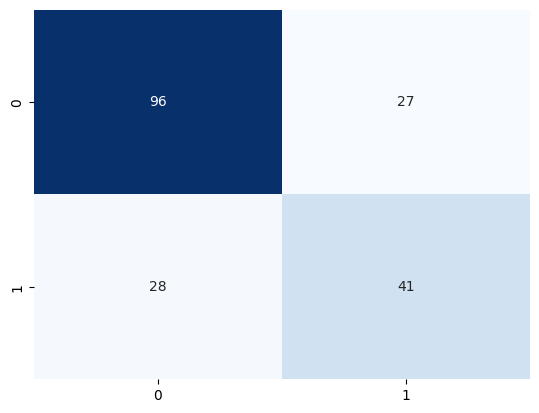

In [188]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

e) Precision-Recall curve

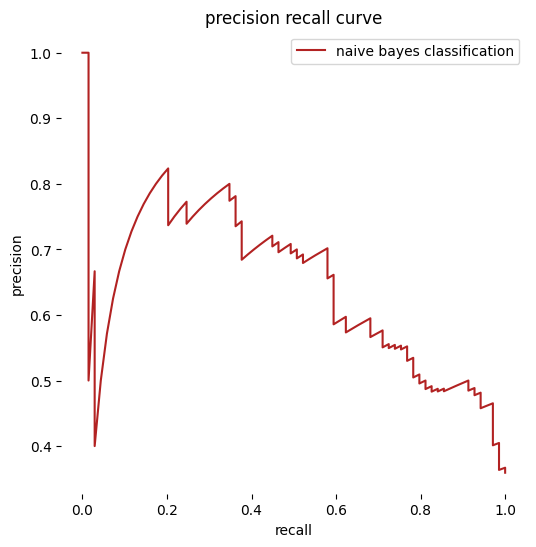

In [189]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(recall, precision, label = 'naive bayes classification', color = 'firebrick')
ax.set_title('precision recall curve')
ax.set_xlabel('recall')
ax.set_ylabel('precision')
plt.box(False)
ax.legend();

f) AUC/ROC curve

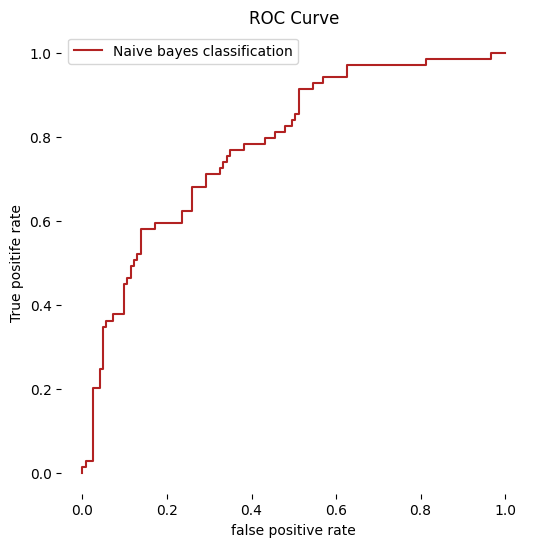

In [190]:
y_pred_proba = classifier.predict_proba(X_test)[:, 1]
fpr, tpr, threshold = metrics.roc_curve(y_test, y_pred_proba)

fig, ax = plt.subplots(figsize=(6,6))
ax.plot(fpr, tpr, label='Naive bayes classification', color ='firebrick')
ax.set_title('ROC Curve')
ax.set_xlabel('false positive rate')
ax.set_ylabel('True positife rate')
plt.box(False)
ax.legend();

9. Visualisation prediction

* Prediction result on the training set

In [191]:
from sklearn.svm import SVC
classifier = SVC(kernel='linear',random_state=0)
classifier.fit(X_train, y_train)

SVC(kernel='linear', random_state=0)

In [192]:
y_pred = classifier.predict(X_test)

In [193]:
from sklearn.metrics import confusion_matrix
cm = confusion_matrix(y_test, y_pred)
cm

array([[100,  23],
       [ 28,  41]])

In [194]:
# Visualising the Training set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_train, y_train
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('naive bayes (Training set)')
plt.xlabel('BloodPressure')
plt.ylabel('SkinThickness')
plt.legend()
plt.show()

ValueError: ignored

In [ ]:
# Visualising the Test set results
from matplotlib.colors import ListedColormap
X_set, y_set = X_test, y_test
X1, X2 = np.meshgrid(np.arange(start = X_set[:, 0].min() - 1, stop = X_set[:, 0].max() + 1, step = 0.01),
                     np.arange(start = X_set[:, 1].min() - 1, stop = X_set[:, 1].max() + 1, step = 0.01))
plt.contourf(X1, X2, classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
             alpha = 0.75, cmap = ListedColormap(('red', 'green')))
plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())
for i, j in enumerate(np.unique(y_set)):
    plt.scatter(X_set[y_set == j, 0], X_set[y_set == j, 1],
                c = ListedColormap(('red', 'green'))(i), label = j)
plt.title('naive bayes (Test set)')
plt.xlabel('Age')
plt.ylabel('Grade')
plt.legend()
plt.show()

10. Example

In [ ]:
print(classifier.predict(sc.transform([[20,  1]])))

* Prediction result on the test set

### Instagram Visitor

In [195]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn import metrics
from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import precision_recall_curve
from sklearn.metrics import confusion_matrix
from sklearn.metrics import f1_score

In [203]:
df = pd.read_csv("/content/Instagram visits clustering (1).csv")
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,63,24.050708
1,1,61,25.223290
2,2,104,18.528245
3,3,82,86.890232
4,4,14,31.492397


a) Drop data (menghapus kolom/atribut yang tidak dibutuhkan)

In [197]:
df = df.drop('Instagram visit score', axis=1)
df.head()

,User ID,Spending_rank(0 to 100)
0,0,24.050708
1,1,25.223290
2,2,18.528245
3,3,86.890232
4,4,31.492397


b) Deskripsi data

In [198]:
df.describe()

,User ID,Spending_rank(0 to 100)
count,2600.000000,2600.000000
mean,1299.500000,42.848408
std,750.699674,28.758349
min,0.000000,0.940709
25%,649.750000,19.452098
50%,1299.500000,28.013082
75%,1949.250000,72.116945
max,2599.000000,107.349821


c) Distribusi data

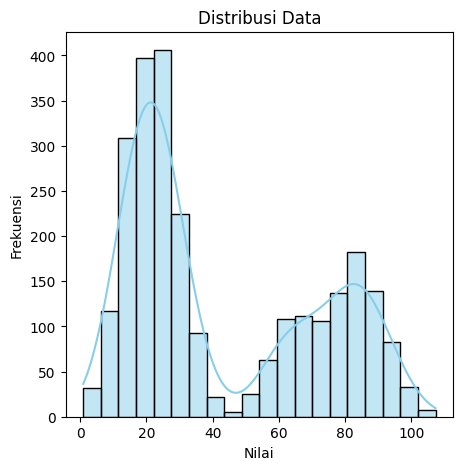

In [200]:
# Visualisasi distribusi menggunakan histogram
plt.figure(figsize=(5, 5))
sns.histplot(df['Spending_rank(0 to 100)'], bins=20, kde=True, color='skyblue', edgecolor='black')

# Menambahkan label dan judul
plt.xlabel('Nilai')
plt.ylabel('Frekuensi')
plt.title('Distribusi Data')

# Menampilkan plot
plt.show()

d) Label encoding

In [205]:
# Inisialisasi objek LabelEncoder
label_encoder = LabelEncoder()

# Menggunakan LabelEncoder pada kolom 'Gender'
df['Instagram visit score'] = label_encoder.fit_transform(df['Instagram visit score'])

In [206]:
df.head()

,User ID,Instagram visit score,Spending_rank(0 to 100)
0,0,57,24.050708
1,1,55,25.223290
2,2,98,18.528245
3,3,76,86.890232
4,4,8,31.492397


e) Correlation matrix

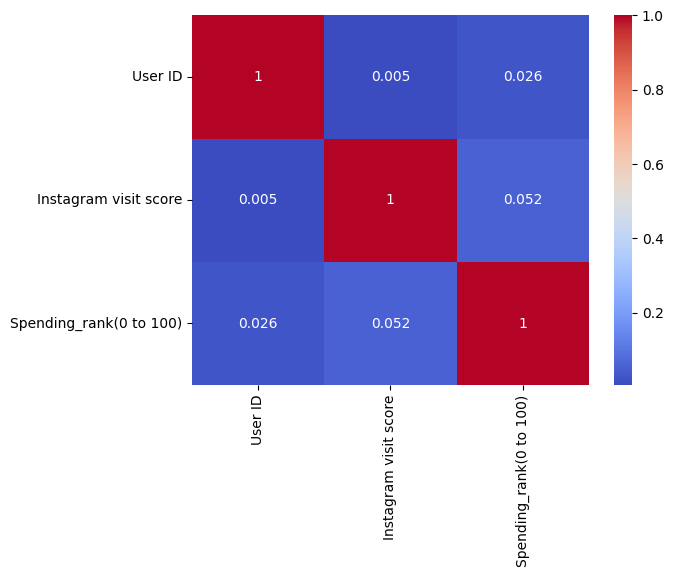

In [207]:
correlation_matrix = df.corr()

sns.heatmap(correlation_matrix, annot = True, cmap = 'coolwarm')
plt.show()

In [208]:
correlation_matrix

,User ID,Instagram visit score,Spending_rank(0 to 100)
User ID,1.000000,0.005019,0.02561
Instagram visit score,0.005019,1.000000,0.05190
Spending_rank(0 to 100),0.025610,0.051900,1.00000


4. Split data

a) Variabel Independen / Dependen

In [209]:
X = df1.iloc[:, :-1].values
y = df1.iloc[:, -1].values

b) Train / Test Split

In [210]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)

5. Feature scaling

In [211]:
sc = StandardScaler()
X_train = sc.fit_transform(X_train)
X_test = sc.transform(X_test)

6. Train model

In [212]:
classifier = GaussianNB()
classifier.fit(X_train, y_train)

GaussianNB()

7. Predict result

In [213]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape( len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [1 1]
 [1 0]
 [0 0]
 [0 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]

a) Akurasi

In [214]:
accuracy_score(y_test, y_pred)

0.7447916666666666

b) Classification report

In [215]:
print(f'classification report : \n{classification_report(y_test, y_pred)}')

classification report : 
              precision    recall  f1-score   support

           0       0.79      0.85      0.82       130
           1       0.62      0.53      0.57        62

    accuracy                           0.74       192
   macro avg       0.71      0.69      0.70       192
weighted avg       0.74      0.74      0.74       192



c) F1 score

In [216]:
f1_scores = f1_score(y_test, y_pred, average=None)
print(f'F1 score for each class: {f1_scores}')

F1 score for each class: [0.81784387 0.57391304]


d) Confusion matrix

<Axes: >

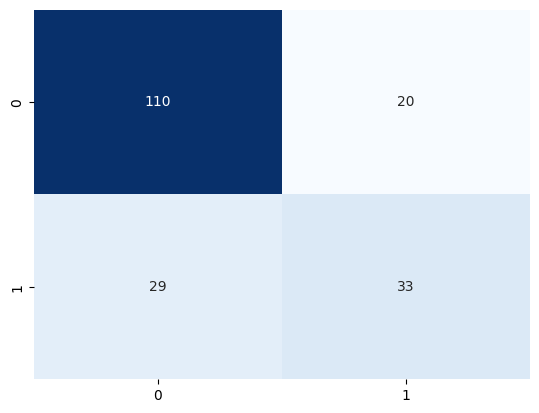

In [217]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)

e) Precision-Recall curve

### SVM

In [220]:
from sklearn.svm import SVC

In [221]:
classifier = SVC(kernel='linear', random_state=0, probability=True)
classifier.fit(X_train, y_train)

SVC(kernel='linear', probability=True, random_state=0)

In [222]:
y_pred = classifier.predict(X_test)
print(np.concatenate((y_pred.reshape(len(y_pred), 1), y_test.reshape(len(y_test), 1)), 1))

[[1 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 1]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 1]
 [1 1]
 [1 1]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [0 1]
 [1 0]
 [1 1]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 1]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [1 1]
 [0 1]
 [1 1]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [0 1]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 1]
 [0 0]
 [0 1]
 [0 0]
 [0 1]
 [1 1]
 [0 0]
 [0 0]
 [1 0]
 [0 0]

In [223]:
accuracy_score(y_test, y_pred)

0.7916666666666666

In [224]:
print(f'classification report : \n{classification_report(y_test, y_pred)}')

classification report : 
              precision    recall  f1-score   support

           0       0.81      0.90      0.85       130
           1       0.73      0.56      0.64        62

    accuracy                           0.79       192
   macro avg       0.77      0.73      0.75       192
weighted avg       0.79      0.79      0.78       192



In [225]:
f1_scores = f1_score(y_test, y_pred, average=None)
print(f'F1 score for each class: {f1_scores}')

F1 score for each class: [0.8540146  0.63636364]


<Axes: >

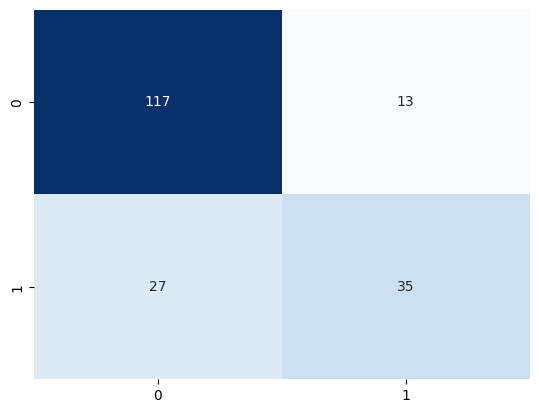

In [226]:
cf_matrix = confusion_matrix(y_test, y_pred)
sns.heatmap(cf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False)